#Sales Overview Analysis

## Objective

The objective of this analysis is to understand the overall sales performance of the business by examining:

- Total Orders
- Total Revenue
- Order Status Distribution
- Monthly Sales Trends
- Sales Performance Over Time

These insights will help evaluate overall business performance and identify important trends.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
df = pd.read_csv('/content/cleaned_amazon_sales.csv')

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 128775
Columns: 19


In [4]:
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 120201


In [5]:
total_revenue = df['Amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 78478115.39000002


## Revenue Observation

The dataset generated a total revenue of Rs 78478115.39 across 120201 orders.

In [6]:
df['Status'].value_counts()

,count
Status,
Shipped,77697
Shipped - Delivered to Buyer,28708
Cancelled,18304
Shipped - Returned to Seller,1949
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


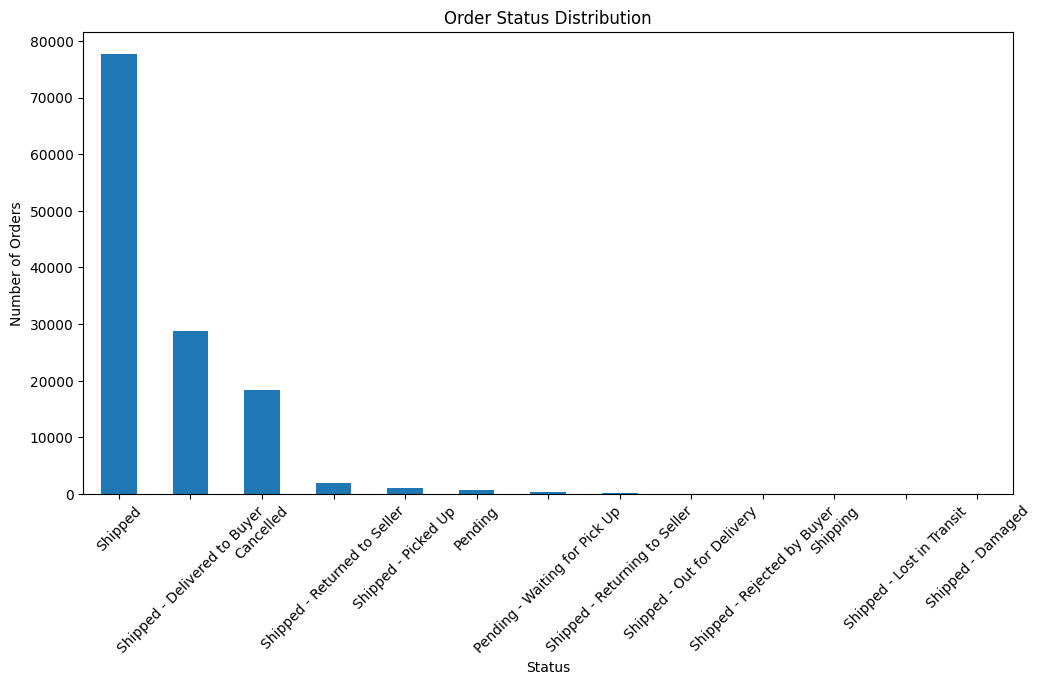

In [7]:
plt.figure(figsize=(12,6))

df['Status'].value_counts().plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

## Order Status Insights

- Most orders fall under Shipped status.
- Cancelled orders represent 14.2% of total orders.
- The majority of orders were successfully shipped.

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['Month'] = df['Date'].dt.to_period('M')

In [10]:
monthly_sales = df.groupby('Month')['Amount'].sum()

monthly_sales

,Amount
Month,
2022-03,101683.85
2022-04,28735357.41
2022-05,26219850.75
2022-06,23421223.38


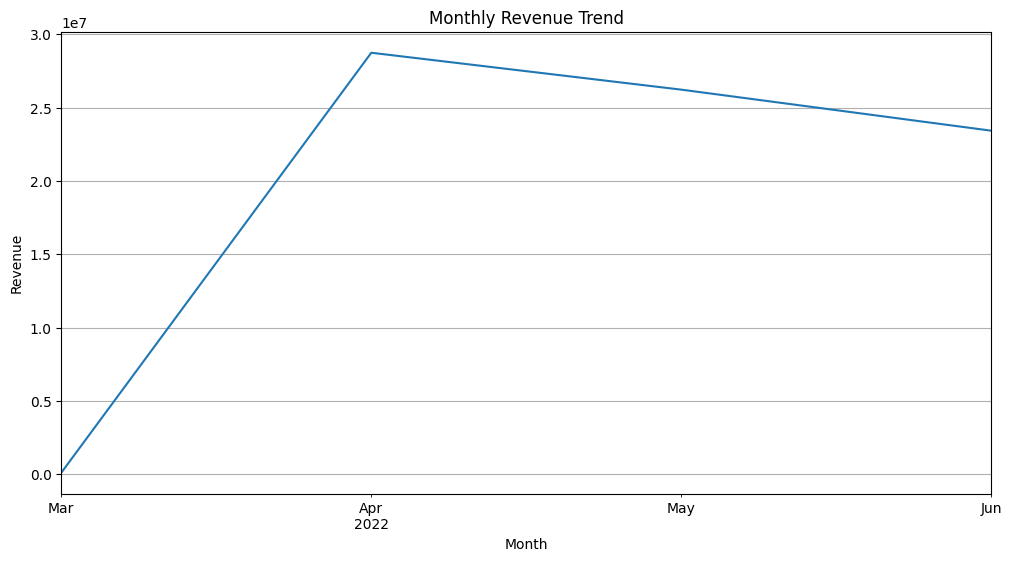

In [11]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

In [12]:
monthly_sales.sort_values(ascending=False).head()

,Amount
Month,
2022-04,28735357.41
2022-05,26219850.75
2022-06,23421223.38
2022-03,101683.85


## Monthly Sales Insights

- Highest Revenue Month: April
- Lowest Revenue Month: March
- Possible Reasons: March revenue appears lower because the dataset contains only a partial month.

In [13]:
df['Amount'].describe()

,Amount
count,120988.000000
mean,648.643794
std,281.235025
min,0.000000
25%,449.000000
50%,605.000000
75%,788.000000
max,5584.000000


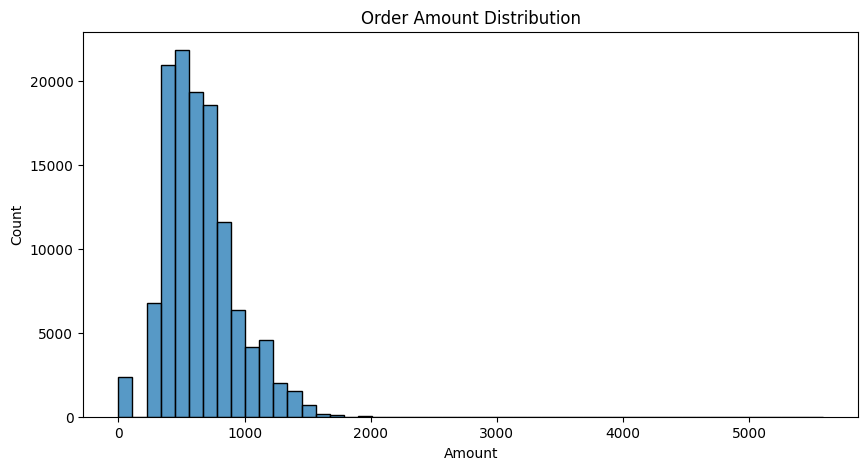

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title('Order Amount Distribution')

plt.show()

In [15]:
avg_order_value = df['Amount'].mean()
print(avg_order_value)

648.6437943432408


# Key Findings

## Sales Overview

1. Total Orders: 120201
2. Total Revenue: 78478115.39
3. Most Common Order Status: Shipped
4. Highest Revenue Month: April
5. Average Order Value: 648.64

## Conclusion

The business demonstrates strong sales performance with consistent revenue generation and a high proportion of successfully fulfilled orders, while showing a gradual decline in monthly revenue after the peak observed in April 2022.